In [4]:
!pip install plotly ipywidgets --quiet


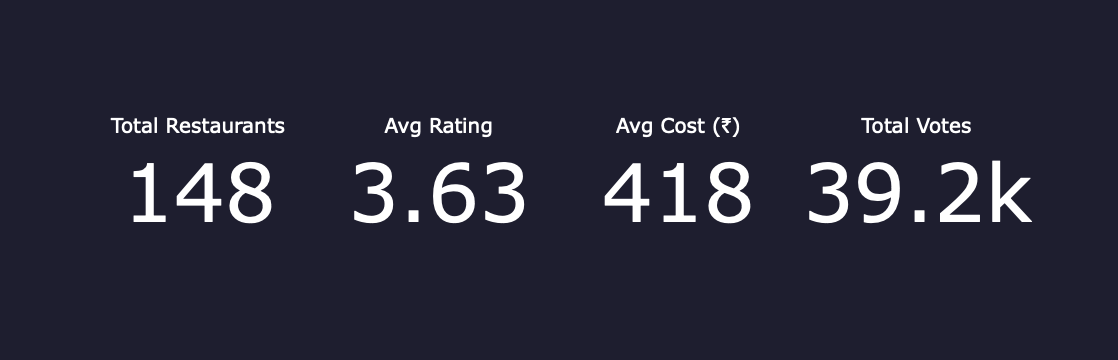

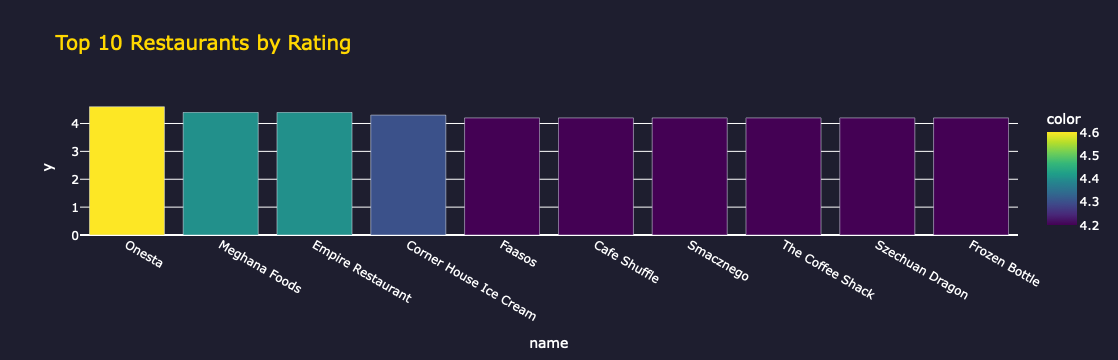

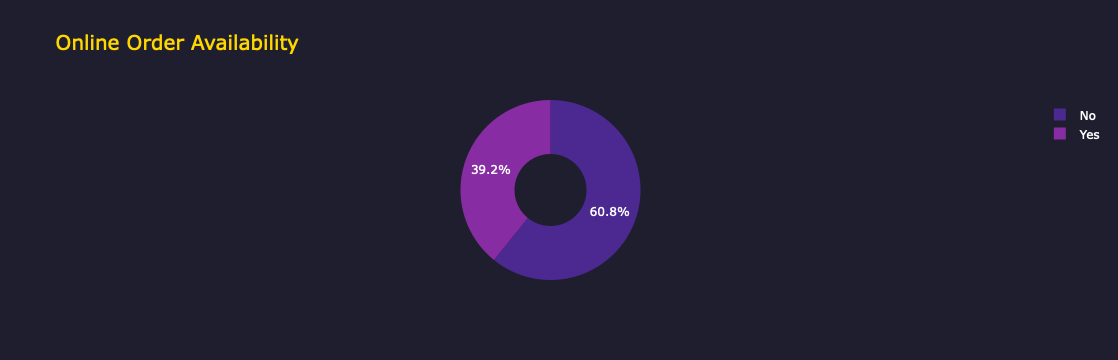

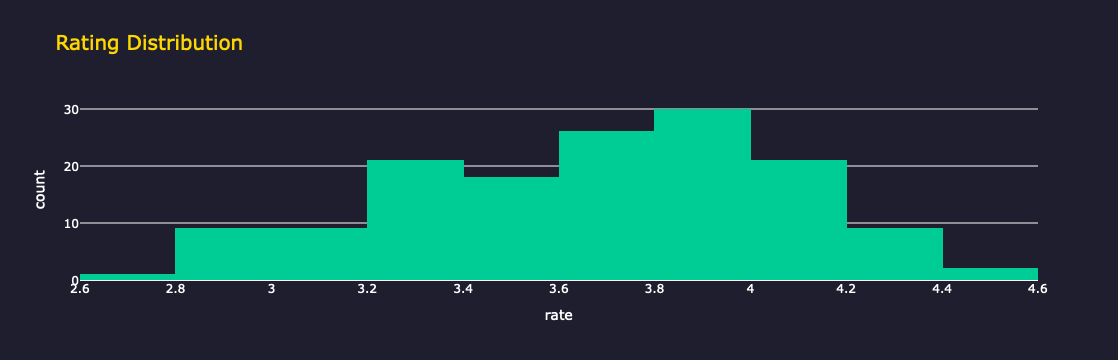

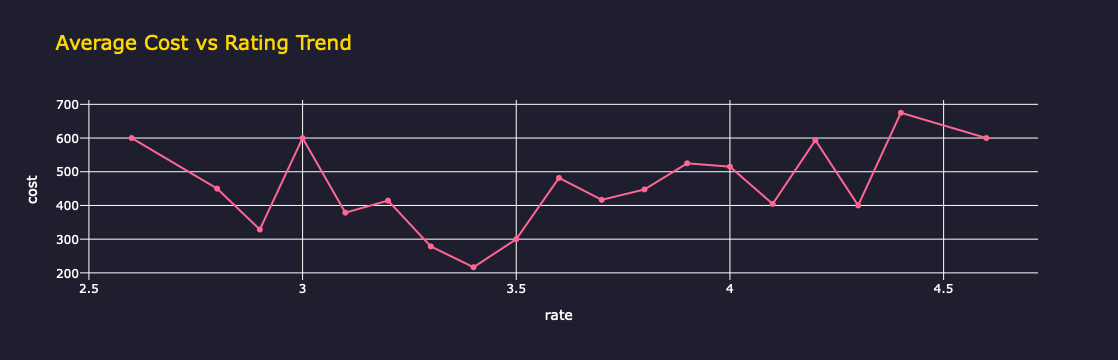

interactive(children=(Dropdown(description='Type:', options=('All', 'Buffet', 'Cafes', 'Dining', 'other'), val…

<function __main__.zomato_bi_dashboard(type_filter, online_order, cost_limit)>

In [26]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown, FloatSlider, VBox, HBox
from IPython.display import display

# ---- Load Dataset ----
df = pd.read_csv('Zomato data .csv')

# ---- Data Cleaning ----
df['rate'] = df['rate'].replace(['NEW', '-'], None)
df['rate'] = df['rate'].str.replace('/5', '', regex=False).astype(float)
df.rename(columns={'approx_cost(for two people)': 'cost'}, inplace=True)
df['cost'] = df['cost'].astype(str).str.replace(',', '', regex=False).astype(float)
df.dropna(subset=['rate', 'cost'], inplace=True)

# ---- Dashboard Function ----
def zomato_bi_dashboard(type_filter, online_order, cost_limit):
    filtered = df.copy()
    if type_filter != 'All':
        filtered = filtered[filtered['listed_in(type)'] == type_filter]
    if online_order != 'All':
        filtered = filtered[filtered['online_order'] == online_order]
    filtered = filtered[filtered['cost'] <= cost_limit]
    
    # ---- KPI CARDS ----
    total_rest = len(filtered)
    avg_rating = round(filtered['rate'].mean(), 2)
    avg_cost = round(filtered['cost'].mean(), 2)
    total_votes = int(filtered['votes'].sum())

    kpi_fig = go.Figure()
    kpi_fig.add_trace(go.Indicator(
        mode="number",
        value=total_rest,
        title={"text": "Total Restaurants"},
        domain={'x': [0, 0.25], 'y': [0, 1]}))
    kpi_fig.add_trace(go.Indicator(
        mode="number",
        value=avg_rating,
        title={"text": "Avg Rating"},
        domain={'x': [0.25, 0.5], 'y': [0, 1]}))
    kpi_fig.add_trace(go.Indicator(
        mode="number",
        value=avg_cost,
        title={"text": "Avg Cost (₹)"},
        domain={'x': [0.5, 0.75], 'y': [0, 1]}))
    kpi_fig.add_trace(go.Indicator(
        mode="number",
        value=total_votes,
        title={"text": "Total Votes"},
        domain={'x': [0.75, 1], 'y': [0, 1]}))
    kpi_fig.update_layout(paper_bgcolor="#1e1e2f", font=dict(color="white", size=14))

    # ---- CHARTS ----
    # 1️⃣ Bar Chart - Top Restaurants
    top = filtered.groupby('name')['rate'].mean().sort_values(ascending=False).head(10)
    fig1 = px.bar(top, x=top.index, y=top.values, color=top.values,
                  color_continuous_scale='Viridis', title='Top 10 Restaurants by Rating')
    fig1.update_layout(paper_bgcolor="#1e1e2f", plot_bgcolor="#1e1e2f",
                       font=dict(color="white"), title_font=dict(size=20, color="gold"))

    # 2️⃣ Pie Chart - Online Order
    fig2 = px.pie(filtered, names='online_order', hole=0.4,
                  title='Online Order Availability', color_discrete_sequence=px.colors.sequential.Agsunset)
    fig2.update_layout(paper_bgcolor="#1e1e2f", font=dict(color="white"), title_font=dict(size=20, color="gold"))

    # 3️⃣ Histogram - Rating
    fig3 = px.histogram(filtered, x='rate', nbins=20, title='Rating Distribution',
                        color_discrete_sequence=['#00CC96'])
    fig3.update_layout(paper_bgcolor="#1e1e2f", plot_bgcolor="#1e1e2f",
                       font=dict(color="white"), title_font=dict(size=20, color="gold"))

    # 4️⃣ Line Chart - Cost vs Rating
    avg_cost_trend = filtered.groupby('rate')['cost'].mean().reset_index().sort_values('rate')
    fig4 = px.line(avg_cost_trend, x='rate', y='cost', markers=True,
                   title='Average Cost vs Rating Trend', color_discrete_sequence=['#FF6692'])
    fig4.update_layout(paper_bgcolor="#1e1e2f", plot_bgcolor="#1e1e2f",
                       font=dict(color="white"), title_font=dict(size=20, color="gold"))

    # ---- Display All ----
    display(kpi_fig)
    fig1.show()
    fig2.show()
    fig3.show()
    fig4.show()

# ---- Controls ----
interact(
    zomato_bi_dashboard,
    type_filter=Dropdown(
        options=['All'] + sorted(df['listed_in(type)'].dropna().unique().tolist()),
        description='Type:'
    ),
    online_order=Dropdown(
        options=['All', 'Yes', 'No'],
        description='Online Order:'
    ),
    cost_limit=FloatSlider(
        value=2000, min=100, max=6000, step=100,
        description='Max Cost:'
    )
)
